In [73]:
import pandas as pd
import numpy as np
import plotly.express as px
from IPython.display import Image

In [74]:
car_df = pd.read_csv("car_prices.csv")

In [75]:
pivot = pd.pivot_table(
    car_df,
    index=["make"],
    aggfunc={"model": "count", "sellingprice": ["sum", "median", "mean"]},
)
pivot.columns = ["_".join(col).strip("_") for col in pivot.columns.values]
pivot = pivot.sort_values(by="sellingprice_sum", ascending=False).reset_index()
top_10_car_makers = pivot.head(10)

In [76]:
result = pivot.loc[
    (pivot["sellingprice_mean"] < 20000)
    & (pivot["sellingprice_mean"] > pivot["sellingprice_median"])
]
total_unit_sold1 = result["model_count"].sum()
result = pivot.loc[
    (pivot["sellingprice_mean"] >= 20000)
    & (pivot["sellingprice_mean"] > pivot["sellingprice_median"])
]
total_unit_sold2 = result["model_count"].sum()
total_unit_sold2

total_sell = {
    "cost": ["Above $20K", "Below $20k"],
    "total_unit": [total_unit_sold2, total_unit_sold1],
}
df = pd.DataFrame(total_sell)

In [77]:
result = (total_unit_sold2 / (total_unit_sold1 + total_unit_sold2)) * 100

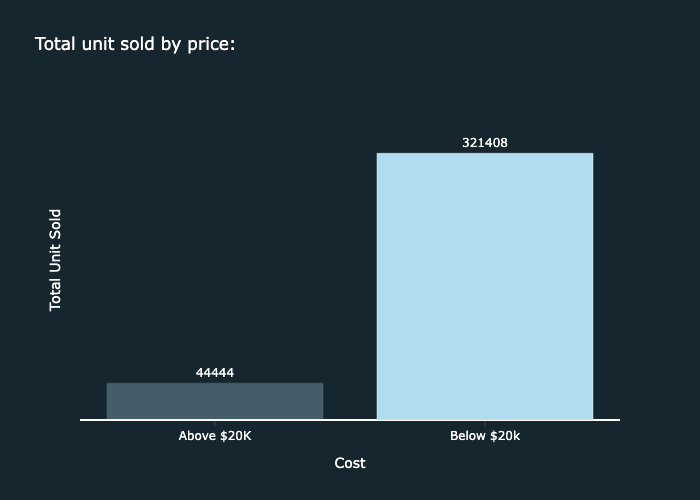

In [78]:
opacity = np.where(df["total_unit"] > 50000, 1, 0.3)
fig = px.bar(
    df,
    x="cost",
    y="total_unit",
    title="Total unit sold by price: ",
    color_discrete_sequence=["#B1DDF1"],
    text="total_unit",
)
fig.update_traces(marker_opacity=opacity, textposition="outside")
fig.update_layout(
    paper_bgcolor="#16262E", plot_bgcolor="#16262E", font=dict(color="#ffffff")
)
fig.update_xaxes(title=dict(text="Cost"), ticks="outside")
fig.update_yaxes(
    showgrid=False,
    showticklabels=False,
    range=[0, df["total_unit"].values.max() * 1.2],
    title=dict(text="Total Unit Sold"),
)
fig.write_image("Total_unit_sol_by_price.png")
Image("Total_unit_sol_by_price.png")

In my analysis the data shows that only 12% of the people bought premium tire cars and they contributed to our company's profit on the other hand 88% is our budget buyers who consider buysing cars which cost less than $20k and still contributed to our companies profit they bought premium tire of the budget segemt that we are offering.


In [79]:
result = pivot.loc[
    (pivot["sellingprice_mean"] < 20000)
    & (pivot["sellingprice_mean"] > pivot["sellingprice_median"])
]
total_unit_sold = result["model_count"].sum()
total_unit_sold

np.int64(321408)

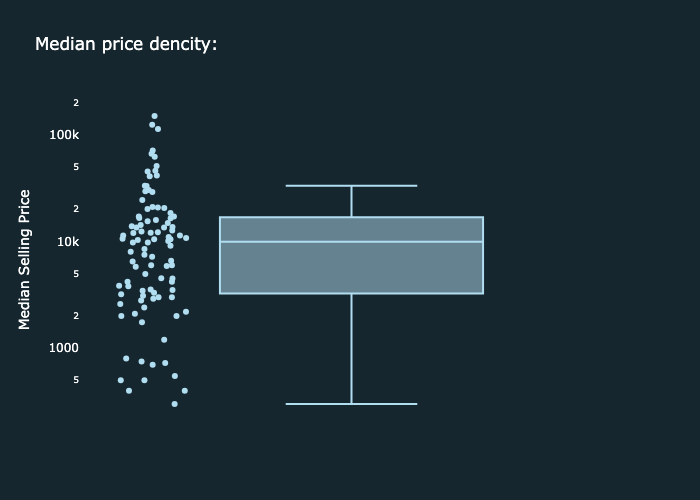

In [80]:
fig = px.box(
    pivot,
    y="sellingprice_median",
    title="Median price dencity:",
    points="all",
    log_y=True,
    color_discrete_sequence=["#B1DDF1"],
)
fig.update_layout(
    paper_bgcolor="#16262E", plot_bgcolor="#16262E", font=dict(color="#ffffff")
)
fig.update_yaxes(
    showgrid=False, zeroline=False, title=dict(text="Median Selling Price")
)
fig.write_image("Median_Price_dencity.png")
Image("Median_Price_dencity.png")

In this box the data shows that vast mejority of the data is below $20k mark this data suggest we need to focus more in the budget segment more to make profit because mejority of the customers are preffering value for money cars. A little amount of our premium tier cars are getting sold by some elite customers as well.


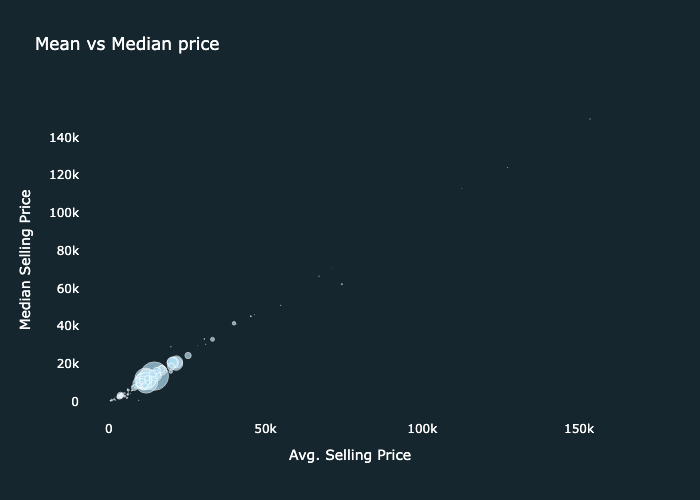

In [81]:
figure = px.scatter(
    pivot,
    x="sellingprice_mean",
    y="sellingprice_median",
    size="model_count",
    color_discrete_sequence=["#B1DDF1"],
    title="Mean vs Median price",
)
figure.update_layout(
    paper_bgcolor="#16262E", plot_bgcolor="#16262E", font=dict(color="#ffffff")
)
figure.update_xaxes(
    showgrid=False, zeroline=False, title=dict(text="Avg. Selling Price")
)
figure.update_yaxes(
    showgrid=False, zeroline=False, title=dict(text="Median Selling Price")
)
figure.write_image("Mean_VS_Median.png")
Image("Mean_VS_Median.png")

In this dataset we can see majority of the sales of the cars are below $20k these are our value for money drivers. We do have some premium divers in this dataset $70k. My analysis suggest most of the premium cars which are >$20k making profits for the company they are selling more premium tire cares than the base model.


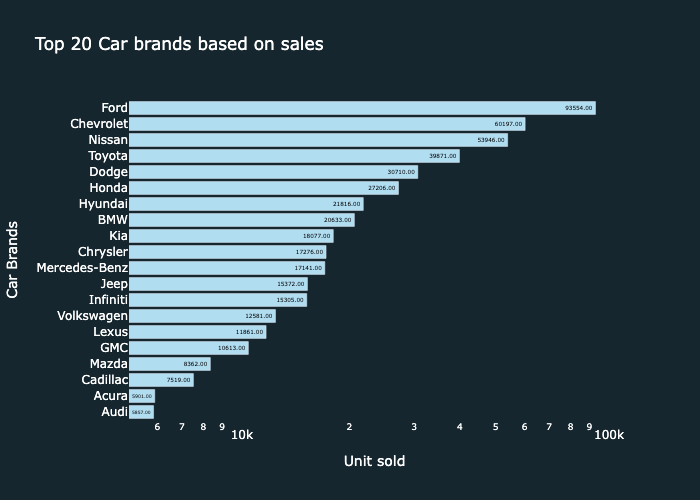

In [82]:
top_20 = pivot.sort_values(by="model_count", ascending=True).tail(20)
figure = px.bar(
    top_20,
    x="model_count",
    y="make",
    log_x=True,
    color_discrete_sequence=["#B1DDF1"],
    title="Top 20 Car brands based on sales",
    text_auto=False,
)
figure.update_traces(
    texttemplate="%{x:.2f}",
    textposition="inside",
    textfont=dict(
        size=20,
        color="black",
    ),
)
figure.update_layout(
    paper_bgcolor="#16262E", plot_bgcolor="#16262E", font=dict(color="#ffffff")
)
figure.update_xaxes(showgrid=False, zeroline=False, title=dict(text="Unit sold"))
figure.update_yaxes(
    showgrid=False, zeroline=False, title=dict(text="Car Brands"), dtick=1
)
figure.write_image("top_car_brands.png")
Image("top_car_brands.png")

This data suggest that ford is no1 in sales thay sold more than 93k followed by Chevrolet with more than 60k unit sold and the 3rd position is held by Nissan with roughly 54k unit sold.


In [83]:
car_df["body"] = car_df["body"].str.capitalize()
body = car_df.pivot_table(
    index="body",
    values=["make", "sellingprice"],
    aggfunc={"make": "count", "sellingprice": ["mean", "median"]},
)
body.columns = ["_".join(col).strip("_") for col in body.columns.values]
body = body.sort_values(by="make_count", ascending=False).reset_index()
body = body.rename(columns={"body": "car_type"})

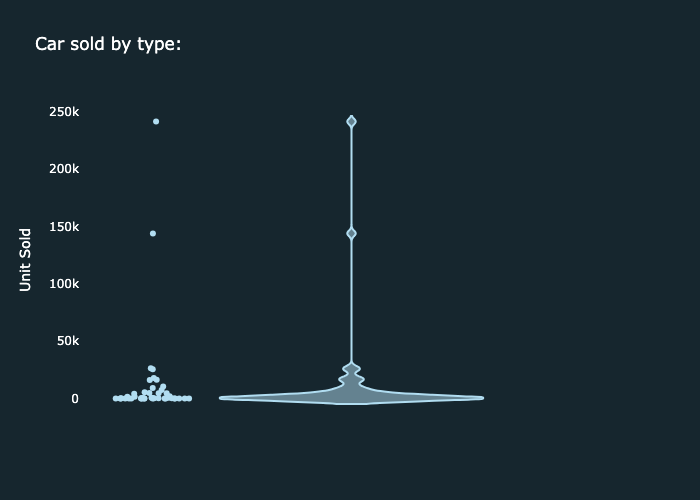

In [84]:
fig = px.violin(
    body,
    y="make_count",
    points="all",
    hover_data={"make_count": True, "car_type": True},
    custom_data="car_type",
    title="Car sold by type: ",
    color_discrete_sequence=["#B1DDF1"],
)
fig.update_traces(
    hovertemplate="<b>Car Type:</b> %{customdata}<br>" + "<b>Unit Sold:</b> %{y:.0f}"
)
fig.update_layout(
    paper_bgcolor="#16262E", plot_bgcolor="#16262E", font=dict(color="#ffffff")
)
fig.update_xaxes(zeroline=True, zerolinecolor="#ffffff")
fig.update_yaxes(title=dict(text="Unit Sold"), showgrid=False, zeroline=False)
fig.write_image("Car_sold_by_Price.png")
Image("Car_sold_by_Price.png")

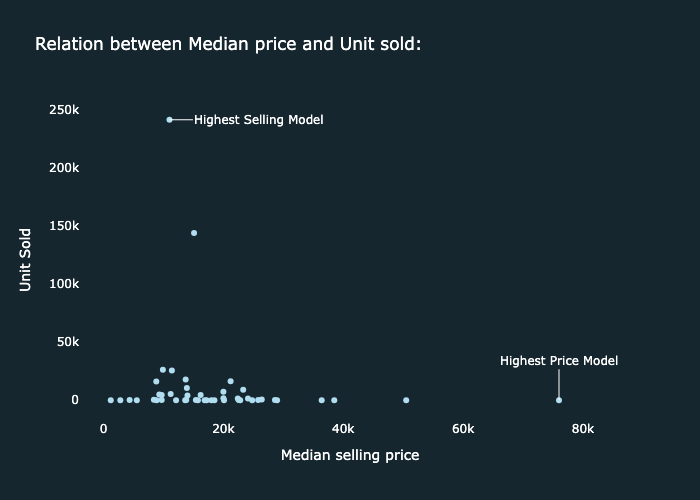

In [85]:
scatter = px.scatter(
    body,
    x="sellingprice_median",
    y="make_count",
    title="Relation between Median price and Unit sold:",
    color_discrete_sequence=["#B1DDF1"],
    hover_data={"make_count": True, "sellingprice_median": True},
    custom_data={"car_type"},
)
scatter.update_traces(
    hovertemplate="<b>Car Type</b>: %{customdata}<br>"
    + "<b>Unit Sold</b>: %{y:.0f}<br>"
    + "<b>Median Price</b>: %{x:.0f}"
)
scatter.update_layout(
    paper_bgcolor="#16262E", plot_bgcolor="#16262E", font=dict(color="#ffffff")
)
scatter.update_xaxes(
    title=dict(text="Median selling price"), showgrid=False, zeroline=False
)
scatter.update_yaxes(title=dict(text="Unit Sold"), showgrid=False, zeroline=False)
scatter.add_annotation(
    x=11000,
    y=241343,
    text="Highest Selling Model",
    arrowhead=True,
    arrowcolor="#ffffff",
    ax=90,
    ay=0,
)
scatter.add_annotation(
    x=76000,
    y=13,
    text="Highest Price Model",
    arrowhead=True,
    arrowcolor="#ffffff",
    ax=0,
    ay=-40,
)
scatter.write_image("median_vs_unitsold.png")
Image("median_vs_unitsold.png")

This dataset tells us that the highest selling car model is "Sedan" class our company sold almost 250k units and the premium car model is "Granturismo Convertible" the median price of the car is $76k and we sold only hand full of them only 13 elite members bought those cars


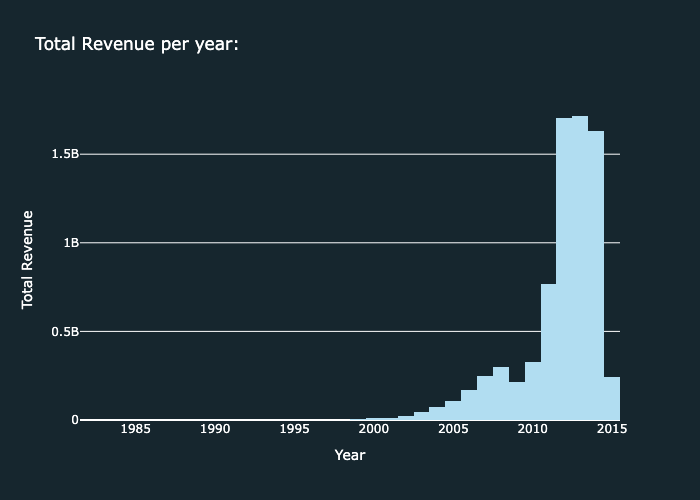

In [86]:
hist = px.histogram(
    car_df,
    x="year",
    y="sellingprice",
    color_discrete_sequence=["#B1DDF1"],
    title="Total Revenue per year:",
    hover_data={"year": True, "sellingprice": True},
)
hist.update_traces(hovertemplate="<b>Year</b>: %{x}<br>" + "<b>Revenue</b>: %{y:.0f}")
hist.update_layout(
    paper_bgcolor="#16262E", plot_bgcolor="#16262E", font=dict(color="#ffffff")
)
hist.update_xaxes(title=dict(text="Year"))
hist.update_yaxes(title=dict(text="Total Revenue"))
hist.write_image("total_rev_by_year.png")
Image("total_rev_by_year.png")

My analysis tells us that our company generated the most revenue in the year of 2013 around $1.7B.


In [87]:
new_updated_dataset = car_df[
    ["year", "make", "body", "transmission", "color", "mmr", "sellingprice"]
].dropna()
new_updated_dataset["price_difference"] = (
    new_updated_dataset["sellingprice"] - new_updated_dataset["mmr"]
)
str_cols = new_updated_dataset.select_dtypes(include="str")
for i in str_cols.columns:
    new_updated_dataset[i] = new_updated_dataset[i].str.title()

In [88]:
new_updated_dataset

,year,make,body,transmission,color,mmr,sellingprice,price_difference
0,2015,Kia,Suv,Automatic,White,20500.0,21500.0,1000.0
1,2015,Kia,Suv,Automatic,White,20800.0,21500.0,700.0
2,2014,Bmw,Sedan,Automatic,Gray,31900.0,30000.0,-1900.0
3,2015,Volvo,Sedan,Automatic,White,27500.0,27750.0,250.0
4,2014,Bmw,Sedan,Automatic,Gray,66000.0,67000.0,1000.0
...,...,...,...,...,...,...,...,...
558831,2011,Bmw,Sedan,Automatic,White,20300.0,22800.0,2500.0
558833,2012,Ram,Crew Cab,Automatic,White,30200.0,30800.0,600.0
558834,2012,Bmw,Suv,Automatic,Black,29800.0,34000.0,4200.0
558835,2015,Nissan,Sedan,Automatic,White,15100.0,11100.0,-4000.0


In [89]:
sar_sale_by_color = new_updated_dataset.pivot_table(
    index="color",
    values=["mmr", "sellingprice", "price_difference"],
    aggfunc={"sellingprice": "sum", "mmr": ["sum", "count"], "price_difference": "sum"},
).reset_index()
sar_sale_by_color.columns = [
    "_".join(col).strip("_") for col in sar_sale_by_color.columns.values
]
sar_sale_by_color = sar_sale_by_color.sort_values(by="mmr_count", ascending=False)
sar_sale_by_color = sar_sale_by_color.loc[
    (sar_sale_by_color["price_difference_sum"] < 0)
]
sar_sale_by_color["discounted_percentage"] = (
    sar_sale_by_color["price_difference_sum"] / sar_sale_by_color["mmr_sum"]
) * 100
sar_sale_by_color = sar_sale_by_color.rename(
    columns={"mmr_sum": "Total MMR", "sellingprice_sum": "Total Selling Price"}
)

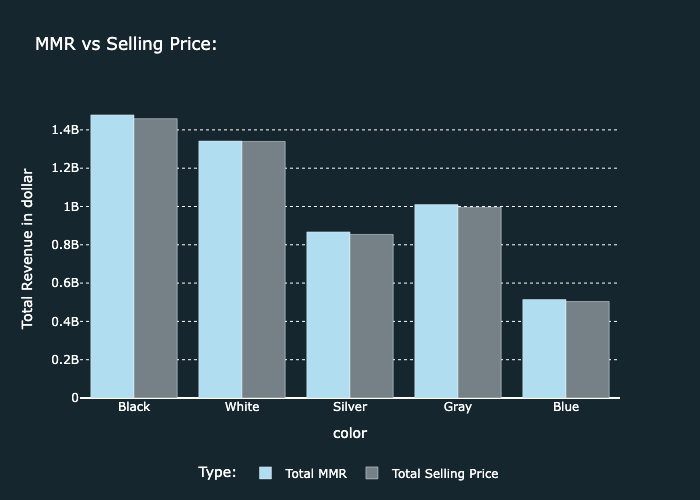

In [102]:
figure = px.bar(
    sar_sale_by_color.head(5),
    x="color",
    y=["Total MMR", "Total Selling Price"],
    barmode="group",
    title="MMR vs Selling Price:",
    color_discrete_sequence=["#B1DDF1", "#768187"],
    hover_data={"value": True},
    custom_data="mmr_count",
)
figure.update_traces(
    hovertemplate="<b>Total Revenue</b>: %{y:.0f}<br>"
    + "<b>Unit Sold</b>: %{customdata}"
)
figure.update_layout(
    paper_bgcolor="#16262E", plot_bgcolor="#16262E", font=dict(color="#ffffff")
)
figure.update_legends(
    title=dict(text="Type:"),
    orientation="h",
    xanchor="center",
    yanchor="bottom",
    x=0.5,
    y=-0.3,
)
figure.update_yaxes(griddash="dot", title=dict(text="Total Revenue in dollar"))
figure.write_image("MMR vs Sellingprice.png")
Image("MMR vs Sellingprice.png")

Our analysis of sales volume versus market valuation (MMR) reveals that black, white, and silver remain the dominant choices in the market collectively accounting for the highest transaction volumes. On average these topselling color categories are trading at approximately 1.2% below the baseline MMR
